<a href="https://colab.research.google.com/github/hsb0205/AI-CLASS/blob/main/WEEK03/wine_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
/content/drive/MyDrive/Colab Notebooks/WEEK03/wine.csv

In [5]:
# wine.csv 파일을 바탕으로 LR, DT, RF Regression 실습
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = '/content/drive/MyDrive/Colab Notebooks/WEEK03/wine.csv'

# DataFrame으로 읽기
df = pd.read_csv(path)
df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [6]:
df2 = df.drop('Wine', axis=1)
df2.head()

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [7]:
# Alcohol 기준으로 예측
y = df2['Alcohol']
y.value_counts()
y

,Alcohol
0,14.23
1,13.20
2,13.16
3,14.37
4,13.24
...,...
173,13.71
174,13.40
175,13.27
176,13.17


In [8]:
X = df2.drop('Alcohol', axis=1)
X.head()

,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [9]:
X = df2.drop('Alcohol', axis=1)
X.head()

,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

from sklearn.metrics import mean_squared_error

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error


--- Linear Regression ---
평균제곱오차(MSE) : 0.4016852023007239
평균제곱오차(MSE) numpy : 0.4016852023007239
평균제곱오차(MSE) 직접구현 : 0.40168520230072396


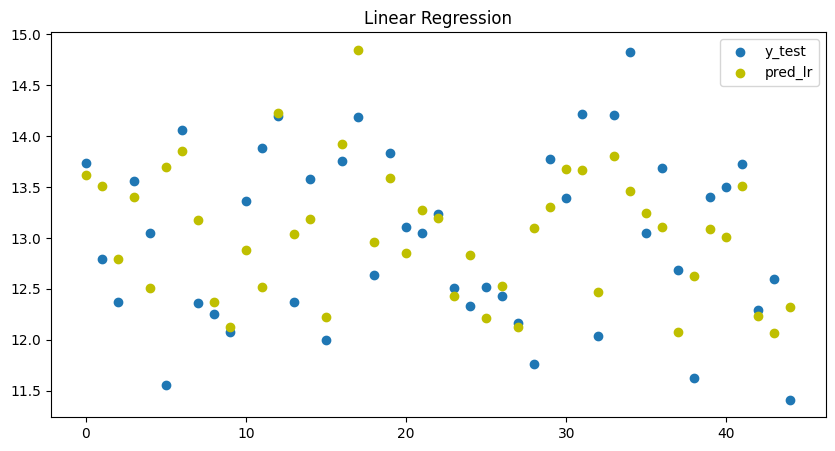

In [11]:
# LR
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

pred_lr = model_lr.predict(X_test)

print('\n--- Linear Regression ---')
print('평균제곱오차(MSE) :', mean_squared_error(y_test, pred_lr))
print('평균제곱오차(MSE) numpy :', mse_np(y_test, pred_lr))
print('평균제곱오차(MSE) 직접구현 :', mse(y_test, pred_lr))

plt.figure(figsize=(10,5))
plt.scatter(range(len(y_test)), y_test, label='y_test')
plt.scatter(range(len(pred_lr)), pred_lr, c='y', label='pred_lr')
plt.title('Linear Regression')
plt.legend()
plt.show()


--- Decision Tree Regressor ---
평균제곱오차(MSE) : 0.6907666666666668
평균제곱오차(MSE) numpy : 0.6907666666666668
평균제곱오차(MSE) 직접구현 : 0.6907666666666665


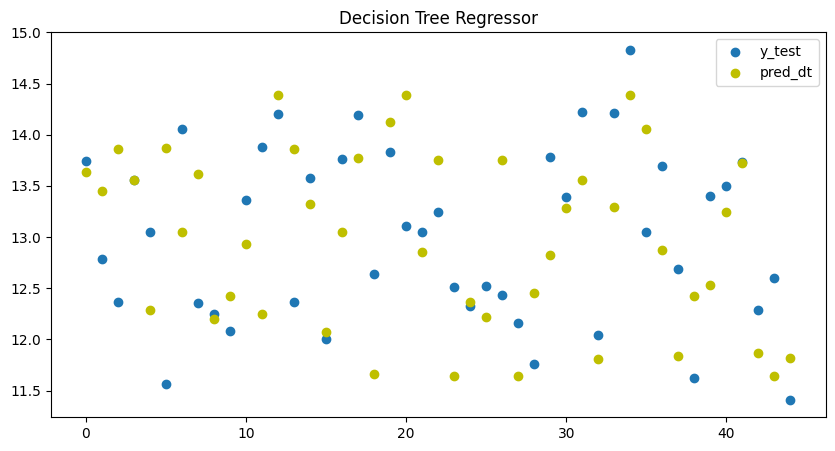

In [12]:
# DT
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(random_state=0)
model_dt.fit(X_train, y_train)

pred_dt = model_dt.predict(X_test)

print('\n--- Decision Tree Regressor ---')
print('평균제곱오차(MSE) :', mean_squared_error(y_test, pred_dt))
print('평균제곱오차(MSE) numpy :', mse_np(y_test, pred_dt))
print('평균제곱오차(MSE) 직접구현 :', mse(y_test, pred_dt))

plt.figure(figsize=(10,5))
plt.scatter(range(len(y_test)), y_test, label='y_test')
plt.scatter(range(len(pred_dt)), pred_dt, c='y', label='pred_dt')
plt.title('Decision Tree Regressor')
plt.legend()
plt.show()


--- Random Forest Regressor ---
평균제곱오차(MSE) : 0.4917587515555531
평균제곱오차(MSE) numpy : 0.4917587515555531
평균제곱오차(MSE) 직접구현 : 0.4917587515555529


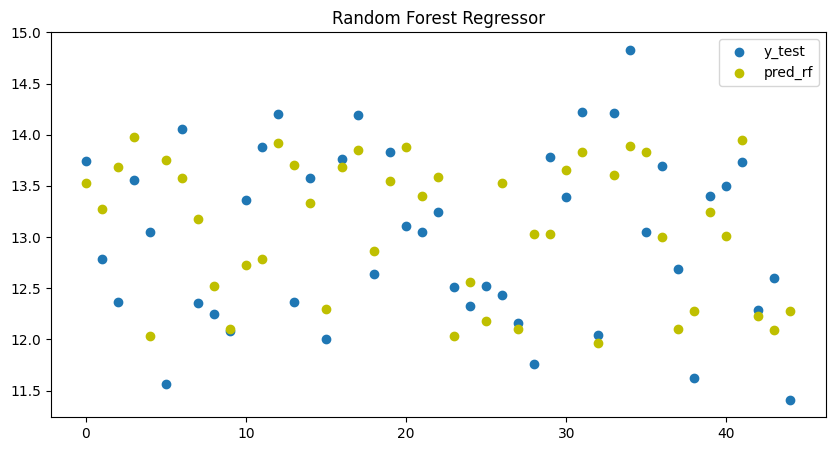

In [13]:
# RF
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=0)
model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)

print('\n--- Random Forest Regressor ---')
print('평균제곱오차(MSE) :', mean_squared_error(y_test, pred_rf))
print('평균제곱오차(MSE) numpy :', mse_np(y_test, pred_rf))
print('평균제곱오차(MSE) 직접구현 :', mse(y_test, pred_rf))

plt.figure(figsize=(10,5))
plt.scatter(range(len(y_test)), y_test, label='y_test')
plt.scatter(range(len(pred_rf)), pred_rf, c='y', label='pred_rf')
plt.title('Random Forest Regressor')
plt.legend()
plt.show()